In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

# Loading data

In [38]:
data_file = "VAL_THO_GF.xlsx"

# excel column to English mapping
cols = {
    'Datum': 'date',
    'Fachabteilung': 'dept',
    'Saal': 'room',
    'Notfallkategorie': 'priority',
    'procedureData_originductionmethod': 'anes-method',

    'In Schleuse': 'arrival_airlock',
    'In Einleitung': 'arrival-induction',
    'documented_anesthesiastarttimestamp': 'anes_start',
    'documented_anesthesiareleasetimestamp': 'anes_release',
    'documented_incisiontimestamp': 'incision',
    'auxilaryData_anesthesiaStartTimestamp': 'planned-anes_start',
    'auxilaryData_anesthesiaReleaseTimestamp': 'planned-anes_release',
    'auxilaryData_incisionTimestamp': 'planned-incision',
    'auxilaryData_expectedAnesthesiaReleaseTimestamp': 'expected-anes_release',
}

# columns with time information
time_cols = ['arrival_airlock', 'arrival-induction', 'anes_start', 'anes_release', 'incision', 'planned-anes_start', 'planned-anes_release', 'planned-incision', 'expected-anes_release']

# loading data
df = pd.read_excel("data/" + data_file, header=0, usecols=cols.keys(), dtype=str)
df = df.rename(columns=cols)

# converting time columns to datetime
for col in time_cols:
    if col in df.columns:
        col_data = df[col]
        if col_data.str.contains(r'\d{4}-\d{2}-\d{2}').any():
            timestamps = pd.to_datetime(col_data, format='%Y-%m-%d %H:%M:%S', errors='coerce')
        elif col_data.str.contains(r'\d{2}\.\d{2}\.\d{4}').any():
            timestamps = pd.to_datetime(col_data, dayfirst=True, errors='coerce')
        df[col] = timestamps

# calculating wait time for anesthesia
df['best-arrival'] = df['arrival-induction'].fillna(df['arrival_airlock'])
df['wait_for_anes_min'] = (df['anes_start'] - df['best-arrival']).dt.total_seconds() / 60
df.loc[df['wait_for_anes_min'] < 0, 'wait_for_anes_min'] = 0

df['total_process_time_min'] = (df['anes_release'] - df['best-arrival']).dt.total_seconds() / 60

# calculating schedule delays
df['delay_start_min'] = (df['anes_start'] - df['planned-anes_start']).dt.total_seconds() / 60
df['delay_release_min'] = (df['anes_release'] - df['planned-anes_release']).dt.total_seconds() / 60
df['delay_incision_min'] = (df['incision'] - df['planned-incision']).dt.total_seconds() / 60
df['delay_release_exp_min'] = (df['anes_release'] - df['expected-anes_release']).dt.total_seconds() / 60



print("--- Average Logistics Metrics ---")
print(f"Average Physical Wait for Anesthesia: {df['wait_for_anes_min'].mean():.1f} mins")
print(f"Average Delay for Anesthesia Start:   {df['delay_start_min'].mean():.1f} mins")
print(f"Average Delay for Anesthesia Release: {df['delay_release_min'].mean():.1f} mins")
print(f"Average Delay for Incision (Surgery): {df['delay_incision_min'].mean():.1f} mins")
print(f"Average Delay for Anesthesia Release from expected value: {df['delay_release_exp_min'].mean():.1f} mins")

--- Average Logistics Metrics ---
Average Physical Wait for Anesthesia: 11.7 mins
Average Delay for Anesthesia Start:   0.0 mins
Average Delay for Anesthesia Release: 0.0 mins
Average Delay for Incision (Surgery): 0.1 mins
Average Delay for Anesthesia Release from expected value: 1.5 mins


# Split data based on clusters

In [39]:
clusters = [['OP2-08', 'OP2-09', 'OP2-10'],['OP2-11', 'OP2-12', 'OP2-13', 'OP2-14']]

all_rooms = df['room'].unique()
rooms_unused = set(all_rooms) - set(clusters[0]) - set(clusters[1])

print(f"Unused rooms: {rooms_unused}")

for c_idx, cluster in enumerate(clusters):
    df.loc[df['room'].isin(cluster), 'cluster'] = c_idx

Unused rooms: {'OP2-07', 'OP3-09', 'OP2-03', 'OP3-04', 'OP3-13', 'OP3-06', 'OP3-03', 'OP3-10', 'OP2-06', 'OP3-11', 'OP2-05', 'OP3-07', 'OP3-02', 'OP3-01', 'OP3-08', 'OP3-05', 'OP3-12', 'OP2-04', 'OP2-16', 'OP2-15'}


# Categorize by anesthesia

In [40]:
def categorize_anesthesia(text):
    if pd.isna(text):
        return "Unknown"

    general = ['AA', 'IVA', 'IZA', 'RSI', 'DLTK', 'ITN']
    regional = ['AXB', 'PDA', 'FEMB', 'SAPHB', 'PIB', 'DIB', 'SPA']
    local = ['INFILTRATION', 'LA', 'LIDOCAIN']


    text = str(text).upper()

    if any(keyword in text for keyword in general):
        return "General"

    if any(keyword in text for keyword in regional):
        return "Regional"

    if any(keyword in text for keyword in local):
        return "Local"

    return "Other"

df['anes-cat'] = df_plot['anes-method'].apply(categorize_anesthesia)

# Find number of neigbours / $\Delta t$

In [41]:
window_min = 10

for clust_idx, cluster in enumerate(clusters):
    clust_df = df[df['cluster'] == clust_idx]
    days = clust_df['date'].unique()

    for day in days:
        df_day = clust_df[clust_df['date'] == day]

        for room in clusters[clust_idx]:
            room_surgeries = df_day[df_day['room'] == room]

            other_rooms = [r for r in clusters[clust_idx] if r != room]
            for idx, surgery in room_surgeries.iterrows():
                curr_time = surgery['best-arrival']

                if pd.isna(curr_time):
                    continue

                closest_deltas = []

                for other_room in other_rooms:
                    other_room_surgeries = df_day[df_day['room'] == other_room]

                    if other_room_surgeries.empty:
                        continue

                    deltas = (other_room_surgeries['best-arrival'] - curr_time).dt.total_seconds() / 60
                    abs_deltas = deltas.dropna().abs()

                    if not abs_deltas.empty:
                        closest_deltas.append(abs_deltas.min())

                if len(closest_deltas) > 0:
                    num_neighbours = sum(d <= window_min for d in closest_deltas)
                    min_delta = min(closest_deltas)
                    avg_delta = sum(closest_deltas) / len(closest_deltas)
                else:
                    num_neighbours = 0
                    min_delta = 1440
                    avg_delta = 1440

                df.loc[idx, 'num_neighbours'] = num_neighbours
                df.loc[idx, 'min_delta'] = min_delta
                df.loc[idx, 'avg_delta'] = avg_delta


# Graph delay x neighbours

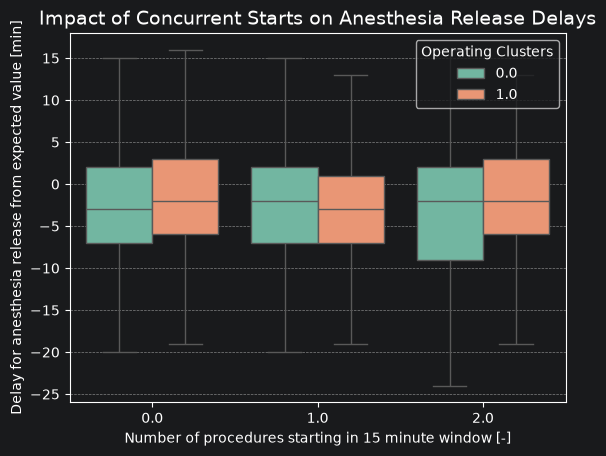

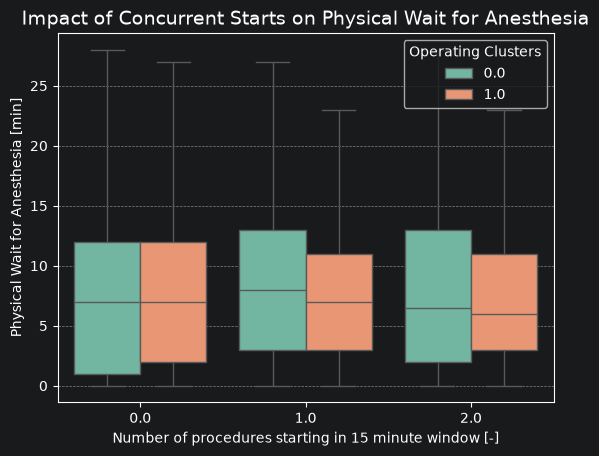

In [42]:
mask = (df['cluster'].notna()) & (df['min_delta'] < 60)
df_plot = df[mask].copy()

plt.figure()
sns.boxplot(
    data=df_plot,
    x="num_neighbours",
    y="delay_release_exp_min",
    hue="cluster",
    palette="Set2",
    showfliers=False,
)
plt.xlabel("Number of procedures starting in 15 minute window [-]")
plt.ylabel("Delay for anesthesia release from expected value [min]")
plt.title("Impact of Concurrent Starts on Anesthesia Release Delays", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Operating Clusters")
plt.show()

plt.figure()
sns.boxplot(
    data=df_plot,
    x="num_neighbours",
    y="wait_for_anes_min",
    hue="cluster",
    palette="Set2",
    showfliers=False,
)
plt.xlabel("Number of procedures starting in 15 minute window [-]")
plt.ylabel("Physical Wait for Anesthesia [min]")
plt.title("Impact of Concurrent Starts on Physical Wait for Anesthesia", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Operating Clusters")
plt.show()

# Graph relationship of minutes of wait time to delta

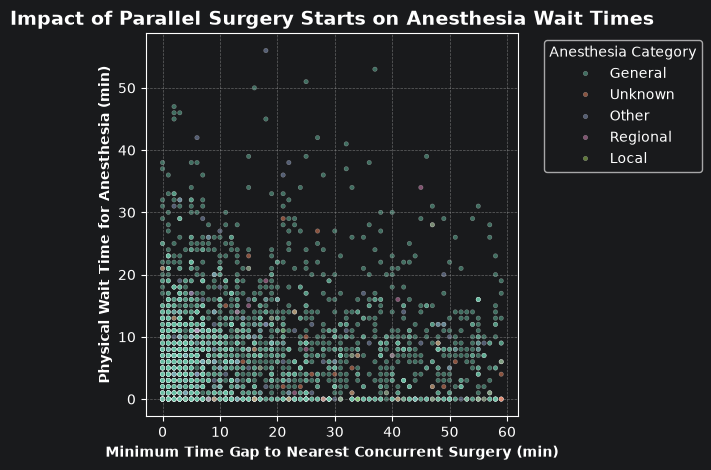

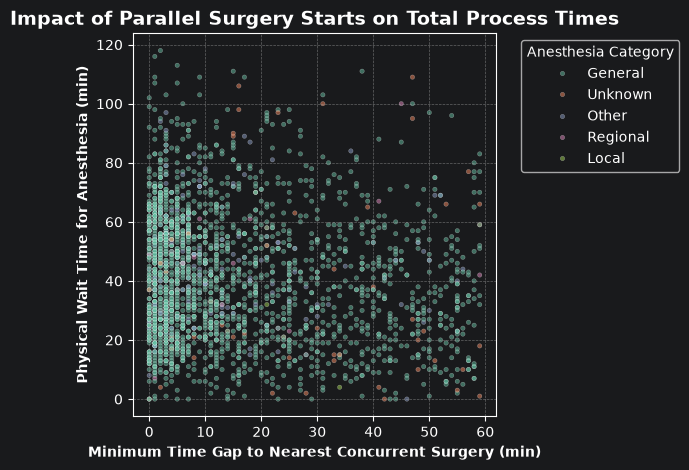

In [58]:
plt.figure()

sns.scatterplot(
    data=df_plot[df_plot['wait_for_anes_min'] <= 60],
    x="min_delta",
    y="wait_for_anes_min",
    hue="anes-cat",
    palette="Set2",
    s=10,
    alpha=0.5,
    legend="full",
)

plt.title("Impact of Parallel Surgery Starts on Anesthesia Wait Times", fontsize=14, fontweight='bold')
plt.xlabel("Minimum Time Gap to Nearest Concurrent Surgery (min)", fontweight='bold')
plt.ylabel("Physical Wait Time for Anesthesia (min)", fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(title="Anesthesia Category", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

plt.figure()

sns.scatterplot(
    data=df_plot[(df_plot['total_process_time_min'] >= 0) & (df_plot['total_process_time_min'] < 120)],
    x="min_delta",
    y="total_process_time_min",
    hue="anes-cat",
    palette="Set2",
    s=10,
    alpha=0.5,
    legend="full",
)

plt.title("Impact of Parallel Surgery Starts on Total Process Times", fontsize=14, fontweight='bold')
plt.xlabel("Minimum Time Gap to Nearest Concurrent Surgery (min)", fontweight='bold')
plt.ylabel("Physical Wait Time for Anesthesia (min)", fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(title="Anesthesia Category", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Proof

In [67]:
df_math = df.dropna(subset=['min_delta', 'wait_for_anes_min', 'anes-cat', 'cluster', 'total_process_time_min']).copy()

mask = (df_math['min_delta'] <= 60) & (df_math['wait_for_anes_min'] <= 60) & (df_math['total_process_time_min'] > 0)
df_zone = df_math[mask]

corr, p_val_corr = stats.spearmanr(df_zone['min_delta'], df_zone['wait_for_anes_min'])
print("### PROOF 1: Cluster Strain (0-60 min window) ###")
print(f"Spearman Correlation Coefficient: {corr:.3f}")
print(f"P-value: {p_val_corr:.2e}")
if p_val_corr < 0.05:
    print("-> CONCLUSION: Mathematically Proven. The time gap and wait time are significantly linked.\n")
else:
    print("-> CONCLUSION: Not Statistically Significant.\n")

general = df_math[df_math['anes-cat'] == 'General']['wait_for_anes_min']
regional = df_math[df_math['anes-cat'] == 'Regional']['wait_for_anes_min']
local = df_math[df_math['anes-cat'] == 'Local']['wait_for_anes_min']

stat, p_val_kw = stats.kruskal(general, regional, local)
print("### PROOF 2: Anesthesia Category Impact ###")
print(f"Kruskal-Wallis Statistic: {stat:.2f}")
print(f"P-value: {p_val_kw:.2e}")
if p_val_kw < 0.05:
    print("-> CONCLUSION: Mathematically Proven. Anesthesia type significantly alters wait times.")
else:
    print("-> CONCLUSION: Not Statistically Significant.")

general_total = df_math[df_math['anes-cat'] == 'General']['total_process_time_min']
regional_total = df_math[df_math['anes-cat'] == 'Regional']['total_process_time_min']
local_total = df_math[df_math['anes-cat'] == 'Local']['total_process_time_min']

stat_total, p_value_total = stats.kruskal(general_total, regional_total, local_total)

print("### PROOF 3: Anesthesia Category Impact on TOTAL Process Time ###")
print(f"Kruskal-Wallis Statistic: {stat_total:.2f}")
print(f"P-value: {p_value_total:.2e}")

if p_value_total < 0.05:
    print("-> CONCLUSION: Mathematically Proven. Anesthesia type significantly alters the total time in holding + anesthesia.\n")
    print(f"General Avg:  {general_total.mean():.1f} mins")
    print(f"Regional Avg: {regional_total.mean():.1f} mins")
    print(f"Local Avg:    {local_total.mean():.1f} mins")
else:
    print("-> CONCLUSION: Not Statistically Significant.")

corr, p_val_corr = stats.spearmanr(df_zone['min_delta'], df_zone['total_process_time_min'])
print("### PROOF 4: Cluster Strain (0-60 min window) ###")
print(f"Spearman Correlation Coefficient: {corr:.3f}")
print(f"P-value: {p_val_corr:.2e}")
if p_val_corr < 0.05:
    print("-> CONCLUSION: Mathematically Proven. The time gap and total process time are significantly linked.\n")
else:
    print("-> CONCLUSION: Not Statistically Significant.\n")

### PROOF 1: Cluster Strain (0-60 min window) ###
Spearman Correlation Coefficient: -0.005
P-value: 8.24e-01
-> CONCLUSION: Not Statistically Significant.

### PROOF 2: Anesthesia Category Impact ###
Kruskal-Wallis Statistic: 0.31
P-value: 8.55e-01
-> CONCLUSION: Not Statistically Significant.
### PROOF 3: Anesthesia Category Impact on TOTAL Process Time ###
Kruskal-Wallis Statistic: 2.34
P-value: 3.10e-01
-> CONCLUSION: Not Statistically Significant.
### PROOF 4: Cluster Strain (0-60 min window) ###
Spearman Correlation Coefficient: -0.121
P-value: 1.04e-08
-> CONCLUSION: Mathematically Proven. The time gap and total process time are significantly linked.



# Calculate Mixed linear model

In [68]:
df_zone = df_zone.rename(columns={'anes-cat': 'anes_cat'})

model = smf.ols(
    formula="total_process_time_min ~ min_delta + C(anes_cat) + C(dept) + C(priority)",
    data=df_zone
).fit()

print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     total_process_time_min   R-squared:                       0.081
Model:                                OLS   Adj. R-squared:                  0.076
Method:                     Least Squares   F-statistic:                     16.16
Date:                    Fri, 03 Jul 2026   Prob (F-statistic):           2.20e-33
Time:                            14:24:57   Log-Likelihood:                -9944.1
No. Observations:                    2226   AIC:                         1.991e+04
Df Residuals:                        2213   BIC:                         1.999e+04
Df Model:                              12                                         
Covariance Type:                nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [66]:
df_zone = df_zone.rename(columns={'anes-cat': 'anes_cat'})

model = smf.ols(
    formula="total_process_time_min ~ num_neighbours + avg_delta + C(anes_cat) + C(dept) + C(priority)",
    data=df_zone
).fit()

print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     total_process_time_min   R-squared:                       0.080
Model:                                OLS   Adj. R-squared:                  0.075
Method:                     Least Squares   F-statistic:                     14.79
Date:                    Fri, 03 Jul 2026   Prob (F-statistic):           1.80e-32
Time:                            14:17:04   Log-Likelihood:                -9891.8
No. Observations:                    2224   AIC:                         1.981e+04
Df Residuals:                        2210   BIC:                         1.989e+04
Df Model:                              13                                         
Covariance Type:                nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [70]:
df['dept'].unique()

<StringArray>
['C2GF', 'C2VAL', 'C2THO']
Length: 3, dtype: str

In [76]:
cols_needed = ['total_process_time_min', 'num_neighbours', 'avg_delta', 'anes_cat', 'priority', 'dept']
df_clean = df_zone[cols_needed].dropna()

model = smf.mixedlm(
    formula="total_process_time_min ~ num_neighbours + avg_delta + C(anes_cat) + C(priority)",
    data=df_clean,
    groups=df_clean["dept"]
)

result = model.fit()
print(result.summary())

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: total_process_time_min
No. Observations: 2226    Method:             REML                  
No. Groups:       3       Scale:              447.9720              
Min. group size:  360     Log-Likelihood:     -9932.7798            
Max. group size:  1132    Converged:          Yes                   
Mean group size:  742.0                                             
--------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------
Intercept                10.477   12.941  0.810 0.418 -14.886 35.840
C(anes_cat)[T.Local]    -25.950   14.992 -1.731 0.083 -55.334  3.434
C(anes_cat)[T.Other]      4.851    1.860  2.608 0.009   1.206  8.496
C(anes_cat)[T.Regional]   2.072    5.024  0.412 0.680  -7.775 11.919
C(anes_cat)[T.Unknown]    1.489    3.221  0.462 0.